#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [2]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [4]:
# Import Eda Libraries
os.chdir(scripts_path)
from exploration import coeff_var_skew, num_uni_hist_box
from ml_eda import lr_features_evaluation, confusion_matrix_display, classification_report_display, roc_curve_display

In [5]:
# Import Advanced Libraries
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, classification_report, roc_curve, auc

In [6]:
# Load & Copy Dataset
os.chdir(data_exploration_path)
original_df = pd.read_csv("eda_processed_data.csv")
df = original_df.copy()

In [7]:
# First Column Drop
df.drop(columns='Unnamed: 0',inplace=True)

In [8]:
# Dataset Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,IsWeekend,Regions,Topic Group
769,8.554,27,48761.14,70.172,1,0,3,3,0,Oceania,1
143,8.367,44,60192.72,93.704,1,0,5,2,1,Oceania,1
222,4.995,39,68737.75,54.636,0,1,3,3,0,Asia,5


#### B. FEATURE ENGINEERING

In [10]:
# Missing Value Check
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
Day                         0
Month                       0
IsWeekend                   0
Regions                     0
Topic Group                 0
dtype: int64

In [11]:
# Area Income: Transformation
df['Area Income_Square'] = np.power(df['Area Income'], 2) # Square

data_positive = df['Area Income']- np.min(df['Area Income']) + 1 # Box Plot
df['Area Income_Boxcox'], _ = boxcox(data_positive)

pt = PowerTransformer(method='yeo-johnson') # Yeo Johnson
df['Area Income_YeoJohnson'] = pt.fit_transform(df[['Area Income']])

In [12]:
# Select Area Income Columns
area_income_ncol = ['Area Income','Area Income_Square','Area Income_Boxcox','Area Income_YeoJohnson']

In [13]:
coeff_var_skew(df,area_income_ncol)

Column:         Area Income
Mean:           55,000.00
Std Dev:        13,414.63
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.65
Skew Interpretation: The data is moderately left-skewed.
----------------------------------------
Column:         Area Income_Square
Mean:           3,204,772,462.35
Std Dev:        1,376,230,319.74
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.10
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_Boxcox
Mean:           3,174,812.96
Std Dev:        1,358,001.31
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.28
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_YeoJohnson
Mean:           0.00
Std Dev:        1.00
CV:             4693596997336096.00
Interpretation: The data is highly spread relative to the mea

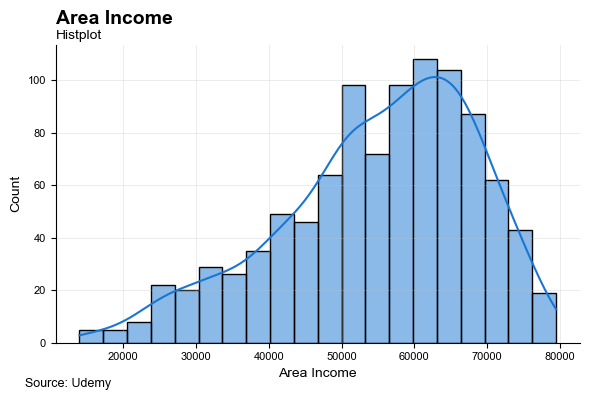

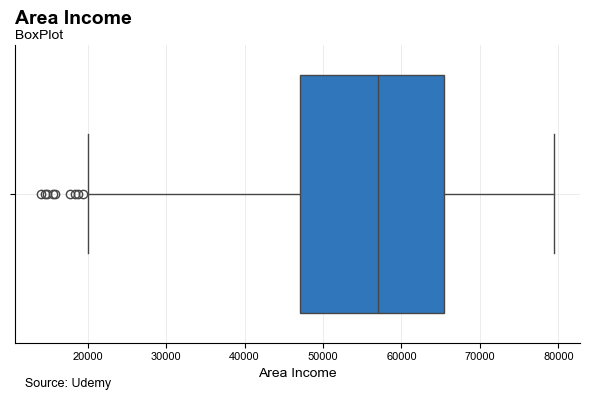

****************************************


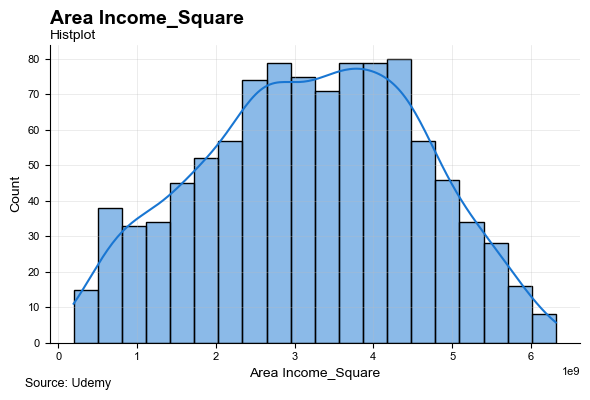

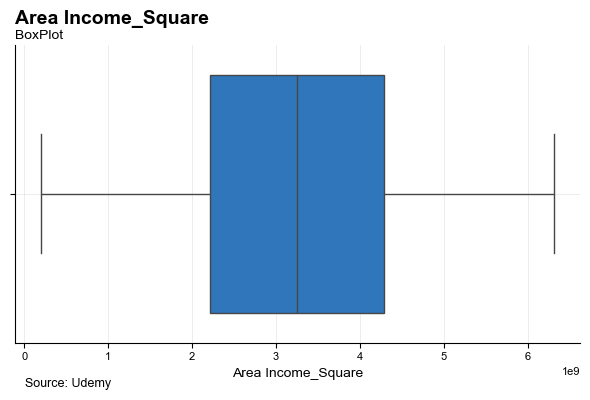

****************************************


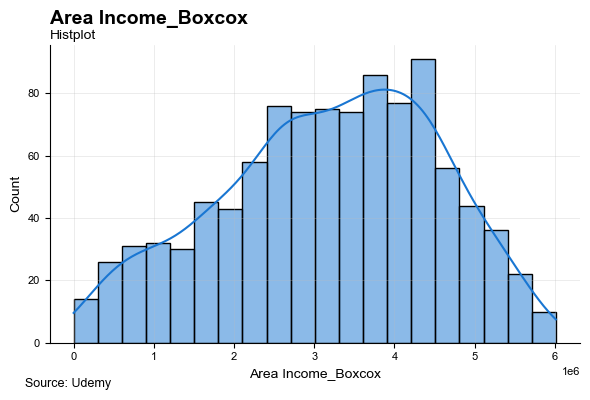

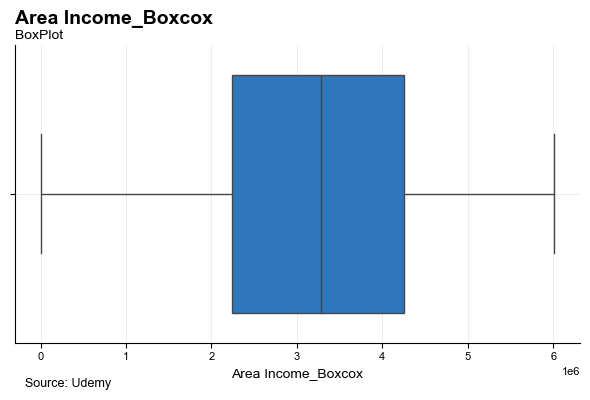

****************************************


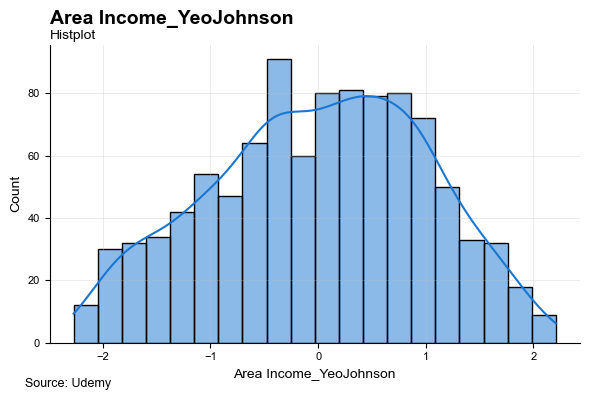

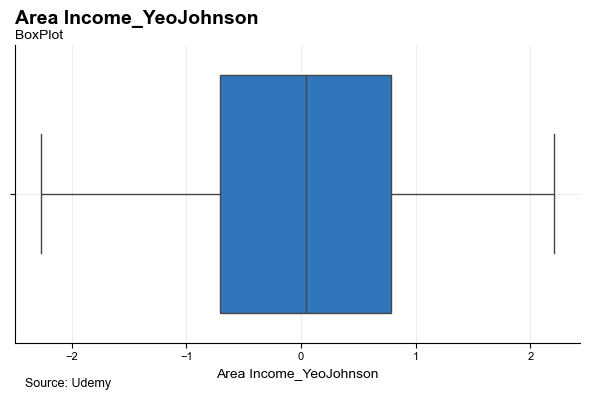

****************************************


In [14]:
# Univeriate Hisplot & Boxplot Display: Area Income
num_uni_hist_box(df,area_income_ncol)

In [15]:
# Drop Unwanted Transformation
df.drop(columns={'Area Income_Boxcox','Area Income_YeoJohnson'},inplace=True)

In [16]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [17]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [18]:
# Convert Booleans
df_processed = df_encoded.astype(int).copy()

#### C. LOGISTIC REGRESSION: DEFAULT

In [20]:
# Define Columns
selected_col = ['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Clicked on Ad', 'IsWeekend',
       'Area Income_Square', 'Day_0', 'Day_1', 'Day_2', 'Day_3', 'Day_4',
       'Day_5', 'Day_6', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5',
       'Month_6', 'Month_7', 'Regions_Africa', 'Regions_Asia',
       'Regions_Europe', 'Regions_Middle East', 'Regions_North America',
       'Regions_Oceania', 'Regions_Others', 'Regions_South America',
       'Topic Group_0', 'Topic Group_1', 'Topic Group_2', 'Topic Group_3',
       'Topic Group_4', 'Topic Group_5']

target_column = 'Clicked on Ad'

In [21]:
# Best Features
result = lr_features_evaluation(df_processed, selected_col, target_column)

Mean Cross-Validation Accuracy: 0.96
Cross-Validation Accuracy Scores: 0.9733333333333334, 0.9733333333333334, 0.94, 0.9533333333333334, 0.96
Feature Coefficients:
----------------------------------------
Feature                   Coefficient
Age                       1.3477
Day_6                     0.4446
Regions_North America     0.3122
Month_5                   0.2849
Regions_Oceania           0.2779
Month_7                   0.2314
Day_0                     0.1320
Topic Group_3             0.1197
Month_4                   0.1115
Topic Group_0             0.1111
Day_4                     0.0916
Topic Group_1             0.0568
Regions_Others            0.0244
Regions_South America     0.0086
Month_1                   0.0000
IsWeekend                 0.0000
Topic Group_4             0.0000
Day_3                     -0.0135
Regions_Middle East       -0.0238
Month_6                   -0.0245
Month_2                   -0.0404
Regions_Europe            -0.0461
Day_2                     

#### D. LOGISTIC REGRESSION: ML ENGINEERING

In [23]:
# Define Columns
selected_col = ['Area Income_Square', 'Daily Internet Usage',
       'Daily Time Spent on Site', 'Age', 'Male', 'Regions_Asia',
       'Regions_North America','Clicked on Ad']

target_column = 'Clicked on Ad'

In [24]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [25]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [26]:
# Load Scaler
scaler = StandardScaler()

In [27]:
# Scale Fit Data
scaler.fit(X_train)

StandardScaler()

In [28]:
# Scale Transform Data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# ML Params
param_grid = {
    'penalty': ['elasticnet'],  # ElasticNet regularization
    'solver': ['saga'],         # Only compatible solver with ElasticNet
    'l1_ratio': [0.1, 0.5, 0.7, 1.0],  # Mix of L1 and L2 regularization
    'C': [0.01, 0.1, 1.0, 10.0],       # Regularization strength
    'max_iter': [1000]         # Higher iterations to ensure convergence
}

In [30]:
# Load Model
lr = LogisticRegression()

In [31]:
# GridSearchCV Load
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

In [32]:
# GridSearch Fit
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1.0, 10.0],
                         'l1_ratio': [0.1, 0.5, 0.7, 1.0], 'max_iter': [1000],
                         'penalty': ['elasticnet'], 'solver': ['saga']},
             scoring='accuracy', verbose=2)

In [33]:
# Best Model
best_model = grid_search.best_estimator_

In [34]:
# Cross-Validation Accuracy
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Accuracy: 0.9747 ± 0.0200


In [35]:
# Best Model Fit
best_model.fit(X_train, y_train)

LogisticRegression(l1_ratio=0.1, max_iter=1000, penalty='elasticnet',
                   solver='saga')

In [36]:
# Best Features
feature_names = X.columns  # Assuming X is your original feature dataframe
coefficients = best_model.coef_[0]  # Coefficients for each feature

# Combine feature names with their corresponding coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Display feature importance
print(feature_importance)

                    Feature  Coefficient
1      Daily Internet Usage    -2.797871
2  Daily Time Spent on Site    -2.600781
0        Area Income_Square    -1.585691
3                       Age     1.320497
4                      Male    -0.431599
6     Regions_North America     0.326269
5              Regions_Asia    -0.074873


In [37]:
# Predict
y_pred = best_model.predict(X_test)

In [38]:
# Predict Probabililty
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

In [39]:
# Confussion Matrix
confusion_matrix_display(y_test, y_pred, labels=['Class 0', 'Class 1'])

Confusion Matrix:
----------------------------------------
                Predicted Class 0  Predicted Class 1
Actual Class 0                116                  4
Actual Class 1                  8                122


In [40]:
# Classification Report Matrix
classification_report_display(y_test, y_pred)

Classification Report:
----------------------------------------
              precision    recall  f1-score  support
0              0.935484  0.966667  0.950820  120.000
1              0.968254  0.938462  0.953125  130.000
accuracy       0.952000  0.952000  0.952000    0.952
macro avg      0.951869  0.952564  0.951972  250.000
weighted avg   0.952524  0.952000  0.952018  250.000


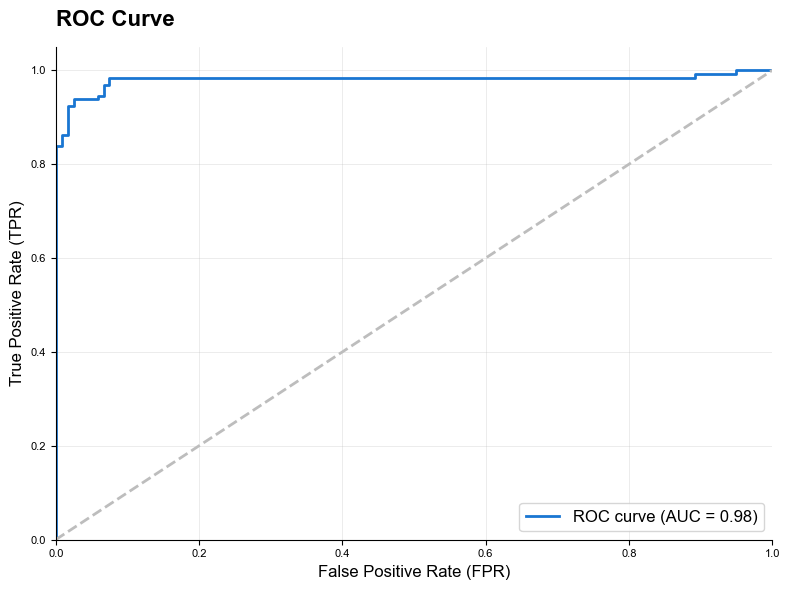

In [41]:
# ROC & AUC Curve
roc_curve_display(y_test, y_pred_prob, plot_title="ROC Curve")

#### E. LOGISTIC REGRESSION: FINAL MODEL

In [43]:
# Define Columns
selected_col = ['Daily Internet Usage','Daily Time Spent on Site','Area Income_Square',
                'Age','Male','Regions_North America','Regions_Asia',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [44]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [45]:
# Load Scaler
scaler = StandardScaler()

In [46]:
# Scale Fit Data
scaler.fit(X)

StandardScaler()

In [47]:
# Scale Transform Data
X = scaler.transform(X)

In [48]:
# Final Model Load
final_model = LogisticRegression(l1_ratio=0.1, max_iter=1000, penalty='elasticnet',solver='saga')

In [49]:
# Final Model Fit
final_model.fit(X, y)

LogisticRegression(l1_ratio=0.1, max_iter=1000, penalty='elasticnet',
                   solver='saga')

In [50]:
# New Values
Daily_Internet_Usage = 1000
Daily_Time_Spent_on_Site = 1000
Area_Income_Square = np.power(24593, 2)
Age = 48
Male = 1
Regions_North_America = 0
Regions_Asia = 1


data = {
    'Daily Internet Usage': [Daily_Internet_Usage],
    'Daily Time Spent on Site': [Daily_Time_Spent_on_Site],
    'Area Income_Square': [Area_Income_Square],
    'Age': [Age],
    'Male': [Male],
    'Regions_North America': [Regions_North_America],
    'Regions_Asia': [Regions_Asia]
}

new_pred = pd.DataFrame(data)
new_pred

,Daily Internet Usage,Daily Time Spent on Site,Area Income_Square,Age,Male,Regions_North America,Regions_Asia
0,1000,1000,604815649,48,1,0,1


In [51]:
# Scale New Predictions
new_pred = scaler.transform(new_pred)

In [52]:
# Predict Probabililty of Clicking
prob_class_0 = round(float(final_model.predict_proba(new_pred)[0][0]*100),2)
prob_class_1 = round(float(final_model.predict_proba(new_pred)[0][1]*100),2)
print(f"\033[1m- Probability of Class 0:\033[0m {prob_class_0}%")
print(f"\033[1m- Probability of Class 1:\033[0m {prob_class_1}%")

- Probability of Class 0: 100.0%
- Probability of Class 1: 0.0%
